---
jupyter: python3
---

<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb)

# Notebook 10: OS, Networks, Cloud & the Web — The Case of the Vanishing Website
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

<!-- Lecture video link to be added -->
📺 **Lecture video:** *(coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain what an operating system does: managing processes, files, and memory
- Describe how a request crosses the internet: IP addresses, DNS, packets, and TCP
- Read an HTTP conversation: requests, responses, and status codes
- Call a real web API with Python's `requests` library and parse the JSON it returns
- Distinguish the cloud service models — IaaS, PaaS, and SaaS — and give an example of each
- Build and run a tiny web server with Flask, and explain the request/response cycle

*Maps to course LOs: 3*

## The Case of the Vanishing Website

**Irene Adler** runs Adler Streaming, a video platform with two million subscribers. This morning, it vanished.

Not for everyone. That's the maddening part. Support tickets say the site is down in Edinburgh but fine in Cardiff. Down on phones, fine on laptops. One customer watched half a film, refreshed, and got nothing.

Irene doesn't panic; she hires. Specifically, she hires **Baker Street Diagnostics**, a two-person consultancy run by **Sherlock Holmes** — a man who believes every technical failure is a crime scene — and **Dr. John Watson**, who translates Sherlock into English.

Sherlock's opening statement, delivered while Irene is still explaining:

> "Your website is not a place, Ms. Adler. It is a *conversation* — a request that leaves a customer's device, crosses machines you've never met, and returns with an answer. Somewhere along that road, the conversation is dying. We will follow the request. Every hop is a suspect. We eliminate them one at a time."

That sentence is this notebook's whole plan.

So far in this course, your programs have lived alone: one file, one machine, no outside world. But almost nothing you actually *use* works that way. Every app on your phone is a conversation between your device and distant computers — crossing an operating system, a network, and somebody's rented cloud.

To find Irene's fault, we have to understand every suspect on the road:

1. **The machine itself** — what an operating system actually does.
2. **The address lookup** — how `adlerstreaming.com` becomes a number a network can use.
3. **The journey** — packets, and the internet's delivery service.
4. **The conversation** — HTTP, the strict little language of the web.
5. **The server's home** — the cloud, and whose computer it really is.

And then the finale: the only way to truly understand a web server is to *become one*. At the end, you'll build and run your own.

## 1. The Machine Underneath: What an Operating System Does

Sherlock starts every case the same way: at the scene, with the body. Here, the "body" is a computer — and the first thing to understand about any computer is that your programs never actually touch it.

Between every program and the physical hardware sits the **operating system** (OS) — Windows, macOS, Linux, Android, iOS. It has three jobs that matter to us:

- **Processes.** A **process** is one running program. The OS starts them, stops them, and slices CPU time among them so that dozens can *appear* to run at once.
- **Files.** The OS owns the disk and organizes it into the **file system** — folders and files with names, so no program has to know where the physical bits live.
- **Memory.** The OS hands each process its own protected slice of memory, so a buggy game can't scribble over your open documents.

A useful mental picture: the OS is a building manager. Programs are tenants. Tenants never wire their own electricity — they ask the manager, and the manager deals with the building.

### The Crime Scene Is a Real Computer

Here's a fact that surprises most people: when you use Google Colab, you're not using "a website" — you've been lent a **real Linux computer** in a Google data center. And Linux will happily let us interrogate it.

In a code cell, a line starting with `!` is not Python — it's a command sent straight to the operating system. The next cell asks the OS to list its running **processes**. Run it in Colab and examine the scene.

In [2]:
#| eval: false
# Run this in Colab: every row is one process (one running program).
!ps aux | head -15

USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND
root           1  0.0  0.0    984   560 ?        Ss   18:12   0:00 /sbin/docker-init -- /datalab/run.sh
root           7  0.1  0.4 1096532 63052 ?       Sl   18:12   0:01 /tools/node/bin/node /datalab/web/app.js
root          20  0.0  0.0   7372  3484 ?        S    18:12   0:00 /bin/bash -e /usr/local/colab/bin/oom_monitor.sh
root          22  0.0  0.0   7372  1832 ?        S    18:12   0:00 /bin/bash -e /datalab/run.sh
root          23  0.0  0.2 1286600 33756 ?       Sl   18:12   0:00 /usr/colab/bin/kernel_manager_proxy --listen_port=6000 --target_port=9000 --logtostderr --listen_host=172.28.0.12 --target_host=172.28.0.12 --tunnel_background_save_url=https://colab.research.google.com/tun/m/cc48301118ce562b961b3c22d803539adc1e0c19/m-s-kkb-use1c2-31zqywppzm7l5 --tunnel_background_save_delay=10s --tunnel_periodic_background_save_frequency=30m0s --enable_output_coalescing=true --output_coalescing_required=true --us

You'll see a table: each row is one process, with its ID number (`PID`), how much CPU and memory it's using, and the command that started it. Somewhere in that list you'll find `python3` — *that row is this notebook*. Your code is just one tenant among many, and the OS is managing all of them at once.

Now the other two jobs — files and memory. The next cell peeks at the top of the file system, then asks the OS how much memory it's handed out.

In [3]:
#| eval: false
# Run this in Colab: the top of the file system, then the memory situation.
!ls /
!free -h

bin	 datalab  home	  lib32   media  proc		    root  srv  tools
boot	 dev	  kaggle  lib64   mnt	 python-apt	    run   sys  usr
content  etc	  lib	  libx32  opt	 python-apt.tar.xz  sbin  tmp  var
               total        used        free      shared  buff/cache   available
Mem:            12Gi       836Mi       8.7Gi       2.0Mi       3.1Gi        11Gi
Swap:             0B          0B          0B


The `ls /` listing shows the standard rooms of a Linux building — `home` (your files), `usr` (installed programs), `tmp` (scratch space). And `free -h` shows the memory ledger: total, used, available. Every byte your Python variables occupy was granted by the OS — and will be reclaimed by it when your process ends.

One picture ties the three jobs together. The diagram below shows where the OS sits.

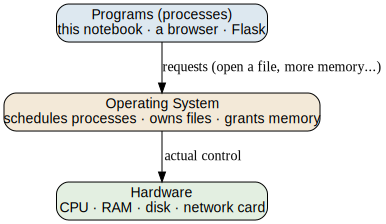

In [4]:
#| echo: false
#@title 📊 Diagram: where the operating system sits (click to show code)
import graphviz

g = graphviz.Digraph()
g.attr(rankdir="TB", bgcolor="transparent")
g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")

g.node("apps", "Programs (processes)\nthis notebook · a browser · Flask", fillcolor="#dde8f0")
g.node("os", "Operating System\nschedules processes · owns files · grants memory", fillcolor="#f3e9d8")
g.node("hw", "Hardware\nCPU · RAM · disk · network card", fillcolor="#e3efe1")

g.edge("apps", "os", label="  requests (open a file, more memory...)")
g.edge("os", "hw", label="  actual control")
g

**Reading it:** every arrow passes through the middle box. Programs at the top never command the hardware directly — they *ask* the OS, and the OS decides. That protection is why one crashing app doesn't take down your whole machine (and why, when a whole *server* goes silent, the OS's process table is the first place a detective looks — remember that for later).

### ✏️ Your Turn — The Scene of the Machine

Sherlock leaves you at the scene with three questions. Answer each by running a command in Colab (use the two cells above as models):

1. How many processes mention `python` in their command? (Try `!ps aux | grep python`.)
2. What's inside the `/tmp` directory right now?
3. Roughly how much memory is *available* on your Colab machine?

In [ ]:
#| eval: false
# TODO: your three investigation commands, one per line.

### 💭 Think About It — Three Hundred Tenants

Your phone is running a few hundred processes *right now* — and you've never had to know that until this sentence.

That ignorance is a designed gift: the OS hides the machine so completely that most people never meet it. What's one other system in your life (not a computer) that works hard so you can ignore it? What happens when *that* one breaks?

## 2. Finding the Address: DNS and IP

The Colab machine checks out — suspect one eliminated. Sherlock moves to the road itself, and brings in a specialist: **Mary Morstan**, whose company, Morstan Logistics, moves fifty thousand parcels a day.

Mary's rule: *"You can't deliver to a name. You deliver to an address."*

The internet agrees. Every machine on a network has an **IP address** — a number like `142.250.187.206`. Numbers, not names, are what the network routes. But nobody types numbers. You type `adlerstreaming.com`, and something must translate.

That something is **DNS** — the Domain Name System: the internet's phone book, translating names into IP addresses millions of times per second, invisibly, before any real conversation begins.

Python can ask DNS directly. The general pattern:

```
socket.gethostbyname("website name")
```

The next cell looks up three real names.

In [ ]:
import socket

for site in ["google.com", "wikipedia.org", "python.org"]:
    print(f"{site:16} -> {socket.gethostbyname(site)}")

google.com       -> 142.251.219.142
wikipedia.org    -> 208.80.154.224
python.org       -> 151.101.128.223


Three names, three numeric addresses — you just used the same lookup your browser performs before loading any page. (Run it twice on different days and `google.com` may answer with *different* numbers. Big sites have many machines behind one name; DNS hands out addresses like a receptionist directing a queue.)

And here is **suspect two** in Irene's case: if a region's DNS servers hold a stale or wrong address, the site "vanishes" — for those users only. Everyone else, using healthy phone books, sees nothing wrong. It fits the Edinburgh tickets... but Sherlock isn't done eliminating.

### The Journey: Packets and TCP

Once your device has the address, Mary's world takes over completely — because data travels the way parcels do.

A message isn't sent whole. It's chopped into **packets** — small chunks, each stamped with the destination address and a sequence number — and each packet finds its *own* way across the network, hopping from router to router. They can arrive out of order. Some don't arrive at all.

The internet's fix is a protocol called **TCP**, and it works exactly like Mary's tracking system:

1. Number every parcel in the shipment.
2. The receiver confirms each one that arrives.
3. Anything unconfirmed gets re-sent.
4. Reassemble in numbered order — the message arrives complete, or the sender knows it didn't.

The diagram below is Sherlock's suspect map: the full road a request travels. Keep it in mind for the rest of the case.

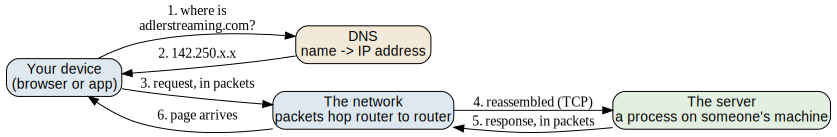

In [5]:
#| echo: false
#@title 📊 Diagram: the road a request travels — the suspect map (click to show code)
import graphviz

g = graphviz.Digraph()
g.attr(rankdir="LR", bgcolor="transparent")
g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fillcolor="#dde8f0")

g.node("browser", "Your device\n(browser or app)")
g.node("dns", "DNS\nname -> IP address", fillcolor="#f3e9d8")
g.node("net", "The network\npackets hop router to router")
g.node("server", "The server\na process on someone's machine", fillcolor="#e3efe1")

g.edge("browser", "dns", label="1. where is\nadlerstreaming.com?")
g.edge("dns", "browser", label="2. 142.250.x.x")
g.edge("browser", "net", label="3. request, in packets")
g.edge("net", "server", label="4. reassembled (TCP)")
g.edge("server", "net", label="5. response, in packets")
g.edge("net", "browser", label="6. page arrives")
g

**Reading it:** follow the numbers. The name lookup (1–2) happens *before* the real request; the request and response (3–6) each cross the network as packets that TCP reassembles. Every box is one of Sherlock's suspects: the device, the phone book, the road, the server.

### The Official Map: The TCP/IP Model

Sherlock's suspect map is homemade. But detectives the world over need to compare notes, so the networking world long ago agreed on one *shared* map: the **TCP/IP model**. It describes every network conversation as four stacked **layers**, each doing one job and relying on the layer below it.

You've already met almost every layer in this notebook — you just didn't know their formal names yet.

| Layer | Its one job | You've met it as... |
|---|---|---|
| **Application** | what the messages *mean* | HTTP, DNS — the conversations (next section) |
| **Transport** | complete, in-order delivery | TCP — Mary's numbered, confirmed parcels |
| **Internet** | addressing and routing | IP addresses; packets hopping router to router |
| **Link** | the physical hop | Wi-Fi, ethernet cable, fiber — the actual wire |

**Reading it:** each layer only talks to the layers directly above and below it. HTTP never worries about lost packets — that's Transport's job. TCP never worries about which cable to use — that's Link's job. This division of labor is *why the internet works*: engineers can replace an entire layer (copper wire → fiber → 5G) without anyone above it noticing. It's the same trick an operating system plays — hide the machinery, expose a promise — stacked four layers high.

### ✏️ Your Turn — Mary's Address Book

Mary wants a mini address book. Look up the IP addresses of **three websites you actually use** (pick your own). Then run your lookups a second time.

Did any address change between runs — or differ from a classmate's result for the same site? Write one sentence proposing *why* a single name might answer with different numbers.

In [ ]:
#| eval: false
import socket

# TODO: look up three sites you use. Run it twice. Compare.
my_sites = ["", "", ""]

## 3. The Conversation: HTTP

The road is clear — Mary's packets are flowing. Sherlock turns to what's *said* on that road. Time to question Irene's site directly, in its own language.

The web's language is **HTTP** (HyperText Transfer Protocol), and it is a rigidly polite conversation with exactly two turns:

- **The request** — your device says: a *verb* (usually `GET`, meaning "please send me...") plus an address.
- **The response** — the server answers with two things: the content, and a three-digit **status code** saying how it went.

Sherlock reads status codes the way he reads witnesses:

| Code | Meaning | Sherlock's translation |
|---|---|---|
| **200** | OK | "The witness is cooperating." |
| **301** | Moved permanently | "He's given a forwarding address." |
| **404** | Not found | "There is no such person at this address." |
| **500** | Server error | "The witness has fainted mid-sentence." |

### Making Requests in Python

Python speaks HTTP through the `requests` library. The pattern couldn't be shorter:

```
response = requests.get("the URL")
response.status_code   # the three-digit verdict
response.json()        # the content, if it's JSON
```

Let's question a real server. Open-Meteo is a free weather service with an API — and since the next section of this case takes us to London, the next cell asks for the current weather near Baker Street.

In [ ]:
import requests

url = "https://api.open-meteo.com/v1/forecast"
response = requests.get(url, params={
    "latitude": 51.52, "longitude": -0.16,   # Baker Street, London
    "current_weather": True,
})

print("Status code:", response.status_code)
print(response.json()["current_weather"])

Status code: 200
{'time': '2026-07-20T21:30', 'interval': 900, 'temperature': 19.8, 'windspeed': 13.3, 'winddirection': 124, 'is_day': 0, 'weathercode': 1}


### Understanding the Code

- `requests.get(url, params=...)` sent a real HTTP request across the real internet — DNS lookup, packets, TCP, everything from the suspect map, in one line.
- `response.status_code` came back `200`: the witness cooperated.
- `response.json()` converted the reply into Python data. The server answered in **JSON** — labeled, nested data that arrives as dictionaries and lists you already know how to handle.

A server whose job is answering programs (rather than showing pages to humans) is called an **API** — an *application programming interface*. This is **Dr. Watson's** world: his telehealth app never scrapes weather off a webpage; it asks an API and gets clean JSON. Most modern software is exactly this — programs having HTTP conversations with other programs.

### Reading the Envelope: Headers

There's more to an HTTP message than its content and its status code. Every request and every response also carries **headers** — labeled notes on the outside of the message, like the writing on an envelope: who sent it, what's inside, how to handle it.

Sherlock, naturally, reads envelopes before letters. The next cell makes a request and inspects three headers from the response.

In [ ]:
import requests

response = requests.get("https://api.github.com")

for header in ["Content-Type", "Server", "Date"]:
    print(f"{header:14}: {response.headers[header]}")

Content-Type  : application/json; charset=utf-8
Server        : github.com
Date          : Mon, 20 Jul 2026 21:32:19 GMT


Three notes on the envelope:

- **Content-Type** tells the receiver how to *read* the body — `application/json` means "parse me as JSON"; a web page would say `text/html`. Your browser obeys this header on every page you visit.
- **Server** is the software that answered — servers introduce themselves.
- **Date** is when the response was written, by the server's own clock.

Headers are where much of the web's hidden machinery lives: logins, cookies, caching rules, security policies. We'll meet the security ones properly in the next notebook — for now, know that every message you send carries an envelope, and the envelope talks.

### 🔮 Predict Before You Run

The next cell deliberately asks GitHub's API for a page that does not exist.

Look at Sherlock's status-code table above. **Before running it**, write down the code you expect.

In [ ]:
import requests

response = requests.get("https://api.github.com/this-page-does-not-exist")
print("Status code:", response.status_code)

Status code: 404


**404 — no such person at this address.** Note what *didn't* happen: no crash, no silence. The server answered, calmly, with a code meaning "that's not a thing." Good HTTP conversations fail *informatively* — and a diagnostician like Sherlock learns as much from a 404 as from a 200.

(As for Irene's site? Her servers are returning 200s... when the request reaches them at all. Suspects three and four — the road and the conversation — are eliminated. The circle tightens.)

### ✏️ Your Turn — Irene's Weather Wall

Irene wants a weather widget for her office wall: the current weather for a city of *your* choice.

Find your city's rough latitude and longitude (search engines answer this instantly), call the Open-Meteo API like the example above, and print **just two things**: the temperature and the wind speed, pulled out of the JSON by key.

In [ ]:
#| eval: false
import requests

# TODO: your city's coordinates, one API call, print temperature and windspeed only.
my_latitude =
my_longitude =

## 4. Whose Computer Is It Anyway? The Cloud

One suspect left: the server itself. But before we knock on its door, Sherlock asks his brother a deceptively simple question: *where does a website live?*

**Mycroft Holmes** runs the Whitehall Cloud Office — he decides where the government's systems live — and his answer is the least mystical definition you'll ever hear:

> "The **cloud** is someone else's computer. Rented by the slice, billed by the hour, reachable over the network. The only interesting question is *how big a slice* you rent."

That question — how much of the machine is your problem versus the landlord's — has exactly three standard answers, and a housing analogy makes them stick:

- **IaaS** (*Infrastructure as a Service*) — **rent bare land.** You get raw virtual machines; you install and manage everything above the hardware. Total control, total responsibility. (Amazon EC2.)
- **PaaS** (*Platform as a Service*) — **rent an apartment.** You bring only your code; the landlord runs the machines, the OS, the plumbing. (Heroku, Google App Engine.)
- **SaaS** (*Software as a Service*) — **book a hotel room.** You just *use* finished software through a browser; nothing underneath is your problem. (Gmail, Google Docs.)

One more row for the table: **you've been a cloud customer this whole course.** Colab is finished software you use through a browser (SaaS) — that hands you a managed machine to run code on (which is what a PaaS does). The Linux box you interrogated in section 1? A slice of someone else's computer, exactly as Mycroft says.

| Model | Housing version | You manage | Example |
|---|---|---|---|
| IaaS | bare land | OS, software, code — everything | Amazon EC2 |
| PaaS | apartment | just your code and data | Heroku, App Engine |
| SaaS | hotel room | nothing — you're a user | Gmail, Colab |

And Irene? Adler Streaming rents from a PaaS. Which means the last suspect — her server — is a *process running on a machine she has never seen.* Hold that thought.

### 💭 Think About It — Mycroft's Dilemma

Mycroft must decide where the national health records system lives: on servers the government owns and staffs, or rented from a giant cloud provider that runs infrastructure better than any government ever has.

Give one strong reason for each choice. Then the harder question: who should hold the keys to data like that — and is "whoever runs servers best" the right answer?

## 5. Becoming the Server

Four suspects eliminated: the client machine, DNS, the network, the HTTP conversation. What remains, however improbable, must be the truth — the fault is *at the server*.

But what actually **is** a server? Strip away the mystique and it's almost disappointing:

> A **server** is a program that waits. It listens for HTTP requests, and for each one, it runs some code and returns a response.

That's it. It's a process — a tenant of some operating system, like every program in section 1. And the fastest way to understand one is to *be* one. Python's most popular tool for this is **Flask**, and its whole shape fits in a skeleton:

```
app = Flask(__name__)

@app.route("/some/path")
def handler():
    return "the response"
```

Each `@app.route(...)` line declares: *when a request arrives for this path, run this function and send back whatever it returns.* A path-plus-function pair is called a **route**.

### First, a Helper to Run Your Servers

A live web server has one awkward habit: it **runs forever**, waiting for requests. If you start it the naive way, the cell freezes on a spinner and nothing else can happen — and re-running the cell tries to grab a port that's already taken and crashes.

So we'll run every server in this notebook through one small helper, `run_web_app`, defined in the next cell. Run it **once** now; you won't need to read it (it's plumbing), but here's what it does for you:

- **Runs the server in the background**, so the cell returns immediately instead of freezing.
- **Is safe to re-run** — it shuts down any previous server on the same port before starting, so you'll never see "port already in use."
- **Shows your site two ways**: an **inline preview** right in the notebook (works for everyone, no login), *and* a pop-out link to a full browser tab.

In [1]:
# ── Run this once. It's plumbing — you don't need to read it. ──
import socket, threading, time
from werkzeug.serving import make_server
from IPython.display import display, HTML

_SERVERS = {}   # remembers running servers so re-running a cell won't crash

def run_web_app(app, port=5000, height=450):
    """Run a Flask app in the background; show it inline + as a pop-out link.
    Safe to re-run: shuts down any previous server on this port first."""
    # 1. Shut down a server already on this port (e.g. from a previous run).
    if port in _SERVERS:
        _SERVERS[port].shutdown()
        del _SERVERS[port]

    # 2. Start Flask in a BACKGROUND thread so this cell doesn't freeze.
    server = make_server("0.0.0.0", port, app)
    _SERVERS[port] = server
    threading.Thread(target=server.serve_forever, daemon=True).start()

    # 3. Wait until the server is really accepting connections — no guessing.
    for _ in range(50):
        with socket.socket() as probe:
            if probe.connect_ex(("127.0.0.1", port)) == 0:
                break
        time.sleep(0.1)

    # 4. Show it. Inline preview first (works for everyone); pop-out link second.
    try:
        from google.colab.output import serve_kernel_port_as_iframe, serve_kernel_port_as_window
        display(HTML(f"<b>✅ Your site is live on port {port}.</b> "
                     f"Preview is below; the pop-out tab needs a Google login."))
        serve_kernel_port_as_iframe(port, height=str(height))
        serve_kernel_port_as_window(port)
    except ImportError:  # not in Colab (e.g. local Jupyter)
        display(HTML(f'<b>Live on port {port}:</b> '
                     f'<a href="http://127.0.0.1:{port}" target="_blank">open your site »</a>'))

> **Why two views?** The pop-out tab uses a Colab feature tied to *your* Google login, so it only opens for people signed into a Google account in Chrome. The **inline preview** has no such requirement — it renders your site right inside the notebook, for everyone. We lead with the inline one.

### A Little HTML: Tags That Wrap Text

Our routes are about to return **HTML** — the language every web page is written in. You don't need to master it; you need a handful of **tags**. A tag wraps a piece of text to say what it *is*, and almost always comes in an open/close pair:

```
<tag>the content goes here</tag>
```

The closing tag is the same word with a slash. These six are all we'll use, and they read almost like English:

| Tag | Wraps text as | Example |
|-----|---------------|---------|
| `<h1>…</h1>` | a big heading | `<h1>Welcome</h1>` |
| `<p>…</p>` | a paragraph | `<p>Hello there.</p>` |
| `<b>…</b>` | **bold** | `<b>open</b>` |
| `<ul>…</ul>` | a bulleted list (the container) | `<ul> … </ul>` |
| `<li>…</li>` | one item inside a list | `<li>First tip</li>` |
| `<a href="/path">…</a>` | a clickable link to `/path` | `<a href="/status">Status</a>` |

That last one — the **link** — is how a visitor travels between your routes, which is exactly what the `NAV` bar below is built from. A page, then, is just a string with a few tags in it. You already know how to build strings.

### Mrs. Hudson Opens the Doors

Naturally, our server will be hosted by a landlady. **Mrs. Hudson** — of Hudson Hosting — presents the next cell: a complete, working web server in about a dozen lines.

Notice two things in it. First, every page returns the same `NAV` bar of links — so once your site is live, you can **click between routes** and watch the request/response cycle happen. Second, the last line hands the app to `run_web_app` instead of blocking forever: no spinner, no stop button, and you can re-run it as often as you like.

In [8]:
from flask import Flask

app = Flask(__name__)

# A shared navigation bar, so every page links to the others.
NAV = ('<nav><a href="/">Home</a> | '
       '<a href="/status">Status</a></nav><hr>')

@app.route("/")
def home():
    return NAV + "<h1>221B Web Services</h1><p>Mrs. Hudson welcomes you.</p>"

@app.route("/status")
def status():
    return NAV + "<h1>Status</h1><p>We are <b>open</b>. Cases solved: <b>47</b>.</p>"

run_web_app(app, port=5000)   # non-blocking, re-runnable, shows inline

<IPython.core.display.Javascript object>

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Use the preview above — or the pop-out tab — and you are *visiting your own website*, served by a process you started on a rented Linux machine in a data center. Click **Status** in the nav bar (or add `/status` to the address) and Flask runs the `status()` function and sends back the page it builds. Look closely at each route: it just returns a **string with a few HTML tags in it** — the heading, paragraph, and bold text you met a moment ago.

Trace one full visit against the suspect map: browser → (address lookup) → packets → **your process** → its return value → packets → rendered page. The **request/response cycle**, end to end — and this time you own the last box.

*(Want a link that works on your phone, off Colab? A tool called `pyngrok` can tunnel your server to a public URL — it needs a free ngrok account and token, so we leave it as an optional side quest.)*

### Routes That Listen: URL Parameters

Mrs. Hudson's two routes are fixed addresses — `/` and `/status` always answer the same way. But think back to section 3: the weather API answered differently depending on the coordinates *you* sent. Real servers listen.

Flask does this by putting a placeholder in the route's path:

```
@app.route("/tip/<int:tip_id>")
def one_tip(tip_id):
    ...
```

The angle brackets declare a **URL parameter**: whatever number appears in that spot of the address becomes the argument `tip_id`, handed straight to your function. Visit `/tip/2`, and `tip_id` is `2`.

The next cell upgrades the server: a list of case tips, and a route that serves any *one* of them by number — politely refusing numbers that don't exist.

In [12]:
from flask import Flask

app = Flask(__name__)

tips = [
    {"id": 1, "from": "anonymous", "tip": "The landlady saw everything."},
    {"id": 2, "from": "Wiggins", "tip": "Check the server logs from Tuesday."},
    {"id": 3, "from": "a concerned neighbor", "tip": "The process died at 3 AM."},
]

# Nav bar with a link to each tip, so you can click through them.
links = " | ".join(f'<a href="/tip/{t["id"]}">Tip #{t["id"]}</a>' for t in tips)
NAV = f"<nav>{links}</nav><hr>"

@app.route("/")
def home():
    return NAV + "<h1>The Tip Line</h1><p>Pick a tip above.</p>"

@app.route("/tip/<int:tip_id>")
def one_tip(tip_id):
    for tip in tips:
        if tip["id"] == tip_id:
            return NAV + f"<h1>Tip #{tip['id']}</h1><p>From <b>{tip['from']}</b>:</p><p>{tip['tip']}</p>"
    return NAV + f"<h1>No such tip</h1><p>There is no tip #{tip_id} on file.</p>", 404

@app.route("/tips")
def tips_page():
    rows = ""
    for tip in tips:
        rows += f"<li><b>Tip #{tip['id']}</b> from {tip['from']}: {tip['tip']}</li>"
    return NAV + f"<h1>The Tip Ledger</h1><ul>{rows}</ul>"

run_web_app(app, port=5000)   # reuses port 5000 — the helper frees it first

<IPython.core.display.Javascript object>

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

### Understanding the Code

- `tips` is a list of dictionaries — the same shape as the JSON you pulled from APIs in section 3. Data in a program and data on a page are the same facts, dressed differently.
- `<int:tip_id>` captures the number from the address and passes it to the function as a real Python `int`.
- The loop searches for a matching tip, then drops its fields into an f-string of HTML tags — a page **built on the spot** from data.
- The last line is the polite refusal: `return page, 404` sets the **status code** yourself. Visit `/tip/99` and you get a clean "no such tip" page *and* a 404 — "no such person at this address," said properly. Your server now *fails informatively*, exactly like the well-behaved APIs you questioned earlier.

### Pages That Are Computed, Not Stored

One more secret of the web, hiding in plain sight: most web pages don't exist until you ask for them.

There is no file anywhere containing your social-media feed or your bank statement page. When your request arrives, a function *builds* that HTML on the spot — from data — and returns it. A page is just a string a server computed. You already know how to compute strings.

The next cell adds one more route — a `/tips` page that lists *all* the tips at once, by looping over the data and gluing together one `<li>` list item per tip.

```python
# You need to copy this to the previous code cell
# Also, add it to the navbar

@app.route("/tips")
def tips_page():
    rows = ""
    for tip in tips:
        rows += f"<li><b>Tip #{tip['id']}</b> from {tip['from']}: {tip['tip']}</li>"
    return NAV + f"<h1>The Tip Ledger</h1><ul>{rows}</ul>"
```

Add this route to the server cell above, re-run, and visit `/tips`: `/tip/2` shows *one* tip, `/tips` shows *all* of them — and neither page exists until you ask. Both are computed from the same list the moment the request arrives.

Real Flask apps keep the HTML in separate files called **templates**, with slots where the data drops in — same idea, tidier housekeeping. You'll see templates again; the concept is the part that matters: *on the modern web, pages are the output of functions.*

One suspect remains in Irene's case. Time to close it.

### Case Closed

Armed with all five layers, Sherlock reads Adler Streaming's server logs — and the culprit is almost insultingly mundane.

One of Irene's three server processes **crashed two days ago**. Nothing restarted it. The two survivors handled the load most of the time — but whenever traffic spiked, requests routed to the dead tenant's address simply... vanished. Down in Edinburgh, fine in Cardiff; down at 8 PM, fine at 3 AM.

One `ps` on the right machine — section 1, the very first tool in this notebook — would have shown a process table with a corpse in it. Sherlock's verdict: *"Your website did not vanish, Ms. Adler. One-third of it stopped existing, and nobody was watching the tenants."*

The fix is a monitor that restarts dead processes. The lesson is the notebook: **the web is layers, and every layer is just something you now understand.**

### ✏️ Your Turn — Your Own Route

Reopen Mrs. Hudson's server cell and add a **third route** at the path `/about` that returns a short HTML paragraph about *you* (or your favorite detective).

Re-run the cell, visit `/about`, and confirm your page is live. Then, for one bonus mark of Sherlock's respect: visit a path you *didn't* define and note what Flask returns.

In [ ]:
#| eval: false
# TODO: copy the server from above, add an /about route, re-run, visit it.

## ✏️ Capstone — The Baker Street Tip Line

Time to run your own corner of the web. You'll design a small web service and have an AI assistant (Gemini, Claude, or ChatGPT) write the Flask code — while you make the design decisions and verify every route.

**The default theme:** an anonymous tip line for Baker Street Diagnostics — a home page, a page that lists all the tips, and a route that looks up one tip by number. **Or reskin it**: a fan site, a team status board, a restaurant menu. Any theme with a page + data works.

### Step 0 — Design First (before touching the AI)

In the cell below, write your design as plain text:

- Your **three routes**: their paths, and what HTML page each returns
- The data behind them (a list of dictionaries is plenty — no database needed)
- One route must take a **URL parameter** — like `/tip/2` returning tip #2

*(Double-click and write your design here.)*

**Route 1:** ...

**Route 2:** ...

**Route 3:** ...

**The data:** ...

### Step 1 — Build It *(prompt #1)*

Turn your design into a prompt. A skeleton to fill in:

> I'm learning Flask in Google Colab. Write a complete Flask app with these three routes: **[paste your design]**.
> Store the data as a Python list of dictionaries defined at the top.
> Give every HTML page a shared `NAV` bar linking to the other routes.
> Do **not** call `app.run(...)`. A helper named `run_web_app(app, port=5000)` is already defined — end the code with that line instead.
> One code block, no explanations.

Paste the result below, run it, and **visit every route** in the opened tab. Don't move on until all three answer.

In [ ]:
#| eval: false
# ✏️ Paste your AI-built Flask app here, run it, and visit every route.

### Step 2 — Question Your Own Witness *(prompt #2)*

In section 3 you interrogated other people's servers with `requests`. Now interrogate **your own** — the two halves of this notebook shaking hands.

While your server cell is running, test like a detective — click and visit, since you can't easily `requests.get` your own Colab tab from outside:

1. Visit each page — does the HTML render? Every field you designed showing up?
2. Visit your parameter route with a number that **exists** — right tip?
3. Visit it with a number that **doesn't exist** — what happens? (If it crashes with an ugly error page: that's a finding. Ask the AI to make it return a polite "not found" page and a `404` status instead.)

In [ ]:
#| eval: false
# ✏️ Paste your improved app here (with the polite 404 handling), re-run, re-test.

### Step 3 — One Extension, Then Reflect

Add **one** bell or whistle — your choice: a route that returns *how many* tips there are; a search route like `/tips/urgent`; or a home page that lists links to every other route. Re-test everything after (a change that breaks an old route is the oldest bug in the book).

Then reflect below, 2–3 sentences: What did the AI get wrong or almost-wrong? What did you only catch by *visiting the routes yourself*?

*AI is a fast first draft. You verify.*

In [ ]:
#| eval: false
# ✏️ Paste your final, extended app here.

*(Your 2–3 sentence reflection — double-click to edit.)*

## Key Terms

- **API (application programming interface)** — A server whose job is answering programs rather than people, usually in JSON.
- **Cloud** — Computers owned by someone else, rented over the network by the slice.
- **DNS (Domain Name System)** — The internet's phone book: translates names like `python.org` into IP addresses.
- **File system** — The OS's organization of storage into named files and folders.
- **Flask** — A small Python library for building web servers.
- **Header** — A labeled note on the outside of an HTTP request or response, like *Content-Type*; the envelope around the message.
- **HTML** — The language web pages are written in: text wrapped in tags (`<h1>`, `<p>`, `<a>`…) that say what each piece *is*.
- **HTTP** — The web's request/response language, spoken between clients and servers.
- **IaaS / PaaS / SaaS** — The three cloud rental sizes: raw machines / a platform for your code / finished software.
- **IP address** — The numeric address that identifies a machine on a network.
- **Operating system (OS)** — The software layer that manages processes, files, and memory between programs and hardware.
- **Packet** — A small, addressed chunk of data; messages cross the internet as many packets.
- **Process** — One running program, managed (started, scheduled, stopped) by the OS.
- **Request/response cycle** — The full round trip: client asks, server's code runs, answer returns.
- **Route** — In a web server, one path (like `/status`) paired with the function that answers it.
- **Server** — A program that waits for requests and returns responses.
- **Status code** — The three-digit verdict in every HTTP response: 200 OK, 404 not found, 500 server error.
- **TCP** — The protocol that numbers, confirms, re-sends, and reassembles packets so messages arrive complete.
- **TCP/IP model** — The standard four-layer map of network communication: application, transport, internet, link.
- **Template** — An HTML file with slots where a server drops data before sending the page; on the modern web, pages are computed, not stored.
- **URL parameter** — A placeholder in a route (like `/tip/<int:tip_id>`) that captures part of the address and passes it to the function.

## Summary

Every app is a conversation across layers, and you now know each one. The operating system runs processes, owns files, and grants memory — programs never touch hardware directly. DNS turns names into IP addresses; TCP moves data as numbered, confirmed packets. On top of that road, HTTP holds a strict two-turn conversation of requests and responses, with status codes as verdicts — and an API is just a server that answers programs in JSON. The cloud is someone else's computer rented in three sizes (IaaS, PaaS, SaaS). And a web server, demystified, is a program that waits: with Flask, a dozen lines make you a citizen of the web rather than a visitor. When something "vanishes," it's one of these layers — and now you know how to interrogate every suspect.

## What's Next

You just built a server and opened its door to the network. Here's the thought that should keep you up tonight: *anyone* can knock. The next notebook is about exactly that — security. Who else is sending requests to your server, what are they after, and how do systems defend the data behind the door?

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*
